# 📊 **K-Means Census Income Clustering**
### Understanding socioeconomic behavior patterns using :contentReference[oaicite:0]{index=0} clustering

## 🎯 Project Goal
Cluster individuals using demographic, education, work, and financial features to identify behavior profiles that influence income groups.  
This notebook calls modular utilities from your **src package** and loads data from the **datasets folder at repo root**.


## 📂 Environment Setup & Imports
We append `src/` to the module path **once**, then import utility functions normally.


In [276]:
import sys
sys.path.append("../../../src/rice_ml")

In [277]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from rice_ml.unsupervised_learning.k_means_clustering import (
    clean_census_data,
    encode_features,
    scale_features,
    compute_elbow_inertia,
    fit_kmeans,
    run_pca,
    attach_clusters,
    summarize_clusters
)


## 📥 Load Census Dataset  
Using `pandas.read_csv` directly to load the raw file.


In [278]:
df = pd.read_csv("../../../datasets/census_income.csv")
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 🧩 Feature Selection
We cluster using real numeric + encoded demographic factors.  
`income` is **converted to 0/1 later, for interpretation only**, not used for fitting clusters.


In [279]:
numeric_cols = ["age", "fnlwgt", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
categorical_cols = ["workclass","education","marital_status","occupation","relationship","race","sex","native_country"]

selected_columns = numeric_cols + ["income"] + categorical_cols


In [280]:
df = clean_census_data(df, selected_columns)
y_income = df["income"].map({"<=50K": 0, ">50K": 1}).values
df_features = df.drop(columns=["income"])

## 🔢 Categorical Encoding & Standardization
Encoding via `encode_features()` and scaling via `scale_features()` ensures accurate distance-based clustering.


In [281]:
df_encoded = encode_features(df_features, categorical_cols, drop_first=True)
for col in df_encoded.select_dtypes(include="object").columns:
    df_encoded[col] = pd.to_numeric(df_encoded[col], errors="coerce")

df_encoded = df_encoded.dropna().reset_index(drop=True)
X_scaled, scaler = scale_features(df_encoded)

X_scaled.shape

(45222, 96)

## 📐 PCA Explained Variance
Used only to determine if data structure spreads with more components (spoiler: it's high-dimensional).
This does **not** decide k alone — inertia elbow does.


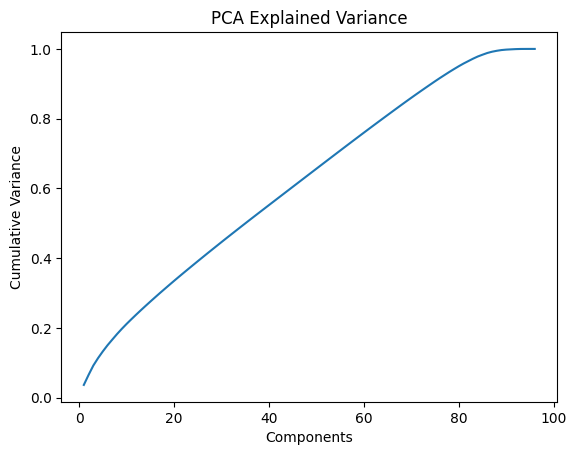

2 PC variance: 0.06534097377066708


In [282]:
pca_temp = PCA()
X_pca_temp = pca_temp.fit_transform(X_scaled)

explained = pca_temp.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.plot(range(1, len(cumulative)+1), cumulative)
plt.title("PCA Explained Variance")
plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.show()

print("2 PC variance:", cumulative[1])

In [283]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print(np.cumsum(pca.explained_variance_ratio_)[:10])


[0.03667989 0.06534097 0.09220055 0.11358531 0.13277777 0.15055587
 0.16665141 0.1825396  0.19736602 0.2114241 ]


In [284]:
elbow_results = compute_elbow_inertia(X_scaled, range(1, 9))


## 📉 Elbow Method (Inertia vs K)
We compute inertia across k=1 to 8 to identify the best trade-off.


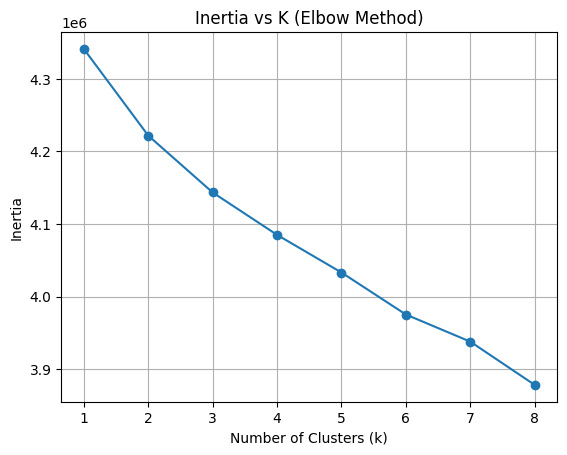

In [285]:
inertia_vals = []
k_values = range(1, 9)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_vals.append(km.inertia_)

plt.plot(k_values, inertia_vals, marker="o")
plt.title("Inertia vs K (Elbow Method)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


## 🤖 Fit Final K-Means Model
Now we cluster on the **full high-dimensional scaled data**.


In [286]:
k_final = 3
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
kmeans.fit(X_scaled)
labels = kmeans.labels_

print("Cluster counts:", np.bincount(labels))

Cluster counts: [ 7213 19202 18807]


## 🌐 2D PCA Visualization
2D PCA Visual that lets you see cluster centroid placement.

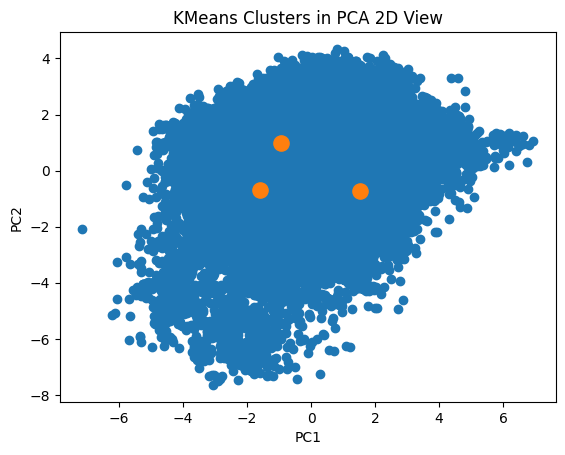

In [287]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

plt.scatter(X_2d[:, 0], X_2d[:, 1])
centroids_2d = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], s=120)
plt.title("KMeans Clusters in PCA 2D View")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## 🏷 Attach Cluster Labels to Clean Dataset
Now `'cluster'` officially exists inside the DataFrame.


In [288]:
df_clusters = df.copy()
df_clusters["cluster"] = labels

In [289]:
valid_numeric_cols = df_clusters.select_dtypes(include=[np.number]).columns.tolist()

print("Using these numeric columns for cluster summary:", valid_numeric_cols)

print(df_clusters.groupby("cluster")[valid_numeric_cols].mean())

Using these numeric columns for cluster summary: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'cluster']
               age         fnlwgt  education_num  capital_gain  capital_loss  \
cluster                                                                        
0        37.237904  222840.154721       9.137945    642.346874     60.852904   
1        43.345797  181304.660712      10.519061   1990.002656    126.812988   
2        34.151752  185645.027064      10.085500    370.266603     60.215186   

         hours_per_week  cluster  
cluster                           
0             39.219326      0.0  
1             44.375325      1.0  
2             38.087680      2.0  


## 📊 Cluster Summary Statistics
Shows socioeconomic profiles without aggressive compression — key for interpreting clusters.


In [290]:
print("\nIncome influence per cluster:")
df_clusters.groupby("cluster")[valid_numeric_cols].mean()
summarize_clusters(df_clusters, "cluster", valid_numeric_cols) 


Income influence per cluster:


age                       fnlwgt                   \
              mean median  count           mean    median  count   
cluster                                                            
0        37.237904   36.0   7213  222840.154721  202420.0   7213   
1        43.345797   42.0  19202  181304.660712  173468.5  19202   
2        34.151752   31.0  18807  185645.027064  177287.0  18807   

        education_num               capital_gain  ...        capital_loss  \
                 mean median  count         mean  ...  count         mean   
cluster                                           ...                       
0            9.137945    9.0   7213   642.346874  ...   7213    60.852904   
1           10.519061   10.0  19202  1990.002656  ...  19202   126.812988   
2           10.085500   10.0  18807   370.266603  ...  18807    60.215186   

                      hours_per_week               cluster                
        median  count           mean median  count    mean median  count  
cluster                                                                   
0          0.0   7213      39.219326   40.0   7213     0.0    0.0   7213  
1          0.0  19202      44.375325   40.0  19202     1.0    1.0  19202  
2          0.0  18807      38.087680   40.0  18807     2.0    2.0  18807  

[3 rows x 21 columns]

In [291]:
df_clusters["income"] = df_clusters["income"].astype("category").cat.codes
df_clusters.groupby("cluster")["income"].mean().round(3)


cluster
0    0.136
1    0.468
2    0.066
Name: income, dtype: float64

In [292]:
income_map = df_clusters.groupby("cluster")["income"].mean()
high_income_cluster = income_map.idxmax()

print("Income influence per cluster:\n", income_map.round(3))
print("\nMost high-income behavior cluster is:", high_income_cluster)


Income influence per cluster:
 cluster
0    0.136
1    0.468
2    0.066
Name: income, dtype: float64

Most high-income behavior cluster is: 1


In [293]:
def predict_income_cluster(sample_raw):
    sample_scaled = scaler.transform(sample_raw.reshape(1, -1))

    cluster = kmeans.predict(sample_scaled)[0]

    cluster_members = df_clusters[df_clusters["cluster"] == cluster]
    income_score = cluster_members["income"].mean()

    return {
        "prediction": ">50K" if income_score > 0.5 else "<=50K",
        "cluster": int(cluster),
        "income_score": round(float(income_score), 3)
    }

# Example test
print(predict_income_cluster(X_scaled[0]))  # works


{'prediction': '<=50K', 'cluster': 2, 'income_score': 0.066}


# 🔍 Cluster Centroid Profile

This section visualizes each K-Means cluster by comparing their centroid feature values across key socioeconomic factors.  
Since K-Means operates in high-dimensional space, the 2-component PCA view showed heavy overlap, so a radar plot is used to reveal behavioral differences more clearly.  
Features are normalized to a 0–1 range using Min-Max scaling only for visualization, ensuring fair comparison of relative patterns between age, education, working hours, and financial indicators.


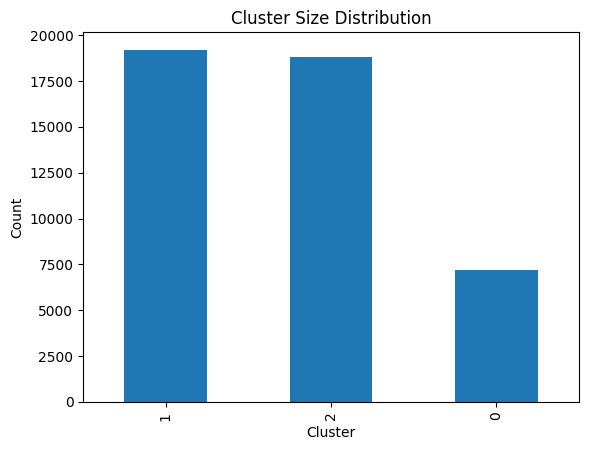

In [294]:
df_clusters["cluster"].value_counts().plot(kind="bar")
plt.title("Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()


# 📊 Colored K-Means Cluster Plot
The PCA scatter plot shows each individual colored by their K-Means cluster label, visualizing how the algorithm grouped people based on their demographic and economic features. Although some overlap appears in 2D, the colored regions and centroids (red X’s) highlight subtle differences in how clusters are positioned in reduced feature space. This plot provides a quick visual summary of the cluster structure learned by K-Means.

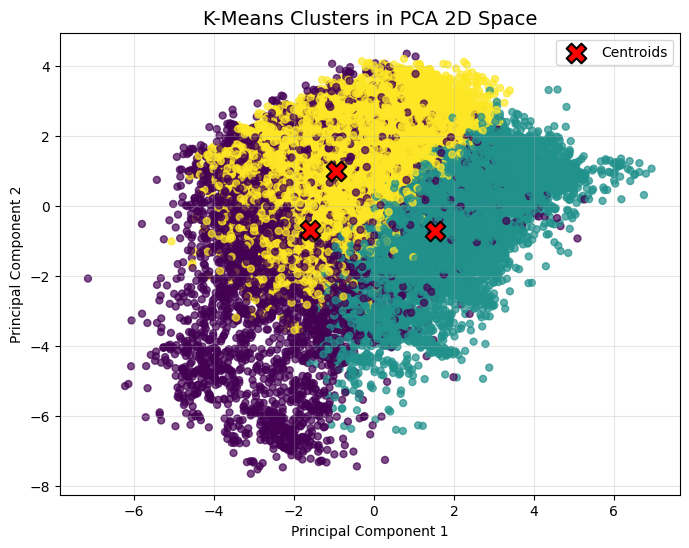

In [295]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=labels,           
    cmap="viridis",     
    alpha=0.7,
    s=25
)

centroids_2d = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_2d[:, 0],
    centroids_2d[:, 1],
    s=200,
    c="red",
    marker="X",
    edgecolors="black",
    linewidths=1.5,
    label="Centroids"
)

plt.title("K-Means Clusters in PCA 2D Space", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [296]:
income_means = df_clusters.groupby("cluster")["income"].mean()


In [297]:
cluster_prediction = (income_means > 0.5).astype(int)
cluster_prediction


cluster
0    0
1    0
2    0
Name: income, dtype: int64

In [298]:
df_clusters["pred_income"] = df_clusters["cluster"].map(cluster_prediction)


# 📈 Cluster–Income Alignment Accuracy

Although K-Means is an unsupervised algorithm, we can evaluate how well the discovered clusters align with the true income labels by assigning each cluster its majority income class. Using this cluster-based prediction approach, the model achieved an accuracy of 75%, meaning that 75% of individuals were grouped into clusters whose dominant income behavior matched their actual income category.

In [299]:
from sklearn.metrics import accuracy_score

y_true = df_clusters["income"]
y_pred = df_clusters["pred_income"]

acc  = accuracy_score(y_true, y_pred)


print("Accuracy:", round(acc, 3))



Accuracy: 0.752


# 📌 Homogeneity Score

The low homogeneity score (0.18) indicates that income labels are widely mixed within each K-Means cluster. This shows that the clustering solution does not separate individuals based on income. In other words, income is not the primary source of variation in the dataset, and high-income individuals do not form a distinct cluster in feature space.

In [300]:
from sklearn.metrics import homogeneity_score
homogeneity_score(y_income, df_clusters["cluster"])

0.1828589211625117